# Gráficos de evolución de datos económicos

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1) Evolución de los tipos oficiales del BCE (2022–2025)

Este cuaderno genera una gráfica con la evolución de:
- Deposit facility
- Main refinancing operations
- Marginal lending facility

Fuente: Banco Central Europeo.

In [21]:
data = [
    ("2022-07-27", 0.00, 0.50, 0.75),
    ("2022-09-14", 0.75, 1.25, 1.50),
    ("2022-11-02", 1.50, 2.00, 2.25),
    ("2022-12-21", 2.00, 2.50, 2.75),
    ("2023-02-08", 2.50, 3.00, 3.25),
    ("2023-03-22", 3.00, 3.50, 3.75),
    ("2023-05-10", 3.25, 3.75, 4.00),
    ("2023-06-21", 3.50, 4.00, 4.25),
    ("2023-08-02", 3.75, 4.25, 4.50),
    ("2023-09-20", 4.00, 4.50, 4.75),
    ("2024-06-12", 3.75, 4.25, 4.50),
    ("2024-09-18", 3.50, 3.65, 3.90),
    ("2024-10-23", 3.25, 3.40, 3.65),
    ("2024-12-18", 3.00, 3.15, 3.40),
    ("2025-02-05", 2.75, 2.90, 3.15),
    ("2025-03-12", 2.50, 2.65, 2.90),
    ("2025-04-23", 2.25, 2.40, 2.65),
    ("2025-06-11", 2.00, 2.15, 2.40),
]

df = pd.DataFrame(
    data,
    columns=[
        "Date",
        "Deposit facility",
        "Main refinancing operations",
        "Marginal lending facility",
    ],
)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df.head()

,Date,Deposit facility,Main refinancing operations,Marginal lending facility
0,2022-07-27,0.00,0.50,0.75
1,2022-09-14,0.75,1.25,1.50
2,2022-11-02,1.50,2.00,2.25
3,2022-12-21,2.00,2.50,2.75
4,2023-02-08,2.50,3.00,3.25


Gráficos

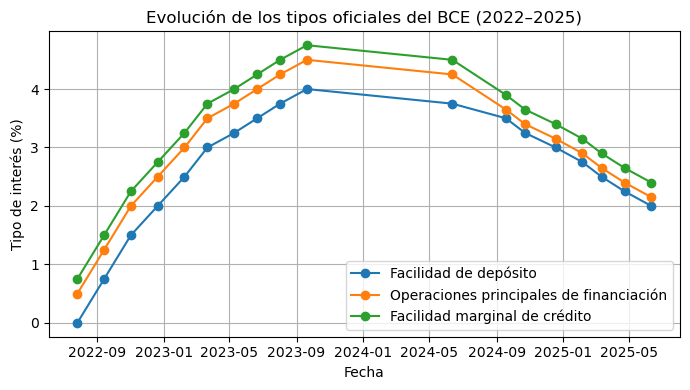

In [22]:
plt.figure(figsize=(7, 4))

plt.plot(df["Date"], df["Deposit facility"], marker="o")
plt.plot(df["Date"], df["Main refinancing operations"], marker="o")
plt.plot(df["Date"], df["Marginal lending facility"], marker="o")

plt.xlabel("Fecha")
plt.ylabel("Tipo de interés (%)")
plt.title("Evolución de los tipos oficiales del BCE (2022–2025)")
plt.grid(True)

plt.legend([
    "Facilidad de depósito",
    "Operaciones principales de financiación",
    "Facilidad marginal de crédito"
])

plt.tight_layout()
plt.show()

### 2) Evolución del Euribor 

Fuente: Idealista

In [39]:
df = pd.read_csv("../data/raw/euribor_raw.txt", sep="\t")

df["value"] = (
    df["Valor"]
      .str.replace("%", "", regex=False)
      .str.replace(",", ".", regex=False)
      .astype(float)
)

month_map = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

df["month"] = df["Mes"].map(month_map)
df = df.rename(columns={"Año": "year"})[["year", "month", "value"]]
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1)
)

df["ma12"] = df["value"].rolling(12, min_periods=1).mean()


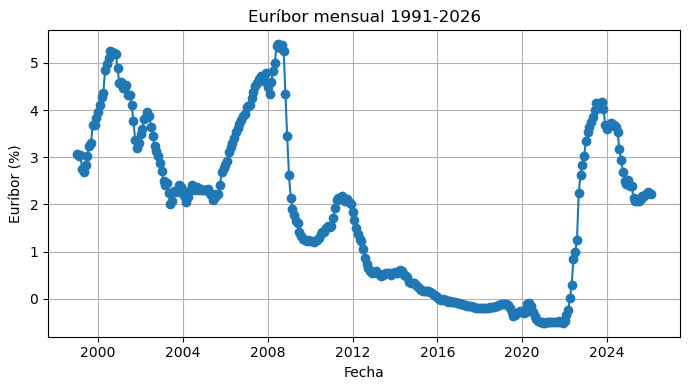

In [60]:
plt.figure(figsize=(7,4))
plt.plot(df["date"], df["value"], marker="o")
plt.xlabel("Fecha")
plt.ylabel("Euríbor (%)")
plt.title("Euríbor mensual 1991-2026")
plt.grid(True)
plt.tight_layout()
plt.show()

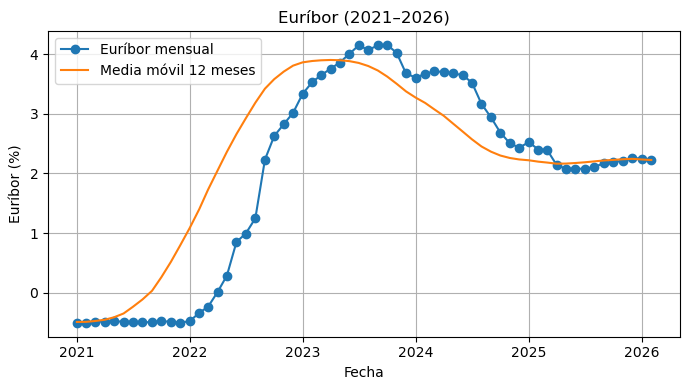

In [59]:
df_zoom = df[df["date"] >= "2021-01-01"]

plt.figure(figsize=(7,4))
plt.plot(df_zoom["date"], df_zoom["value"], marker="o")
plt.plot(df_zoom["date"], df_zoom["ma12"])
plt.xlabel("Fecha")
plt.ylabel("Euríbor (%)")
plt.title("Euríbor (2021–2026)")
plt.grid(True)
plt.legend(["Euríbor mensual", "Media móvil 12 meses"])
plt.tight_layout()
plt.show()

    Año     media  minimo  maximo
0  2021 -0.490750  -0.505  -0.477
1  2022  1.087667  -0.477   3.018
2  2023  3.864667   3.337   4.160
3  2024  3.274000   2.433   3.716
4  2025  2.221833   2.079   2.526
5  2026  2.235500   2.226   2.245


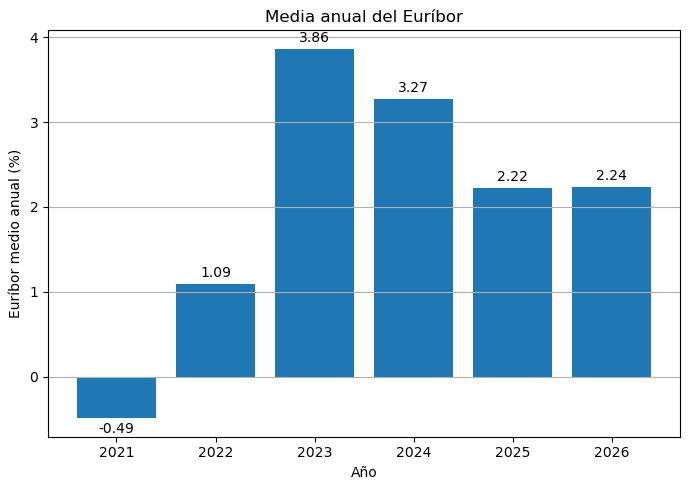

In [57]:
df_year = (
    df_zoom
      .assign(Año=df_zoom["date"].dt.year)
      .groupby("Año")
      .agg(
          media=("value", "mean"),
          minimo=("value", "min"),
          maximo=("value", "max")
      )
      .reset_index()
)

print(df_year)

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(df_year["Año"], df_year["media"])

ax.set_xlabel("Año")
ax.set_ylabel("Euríbor medio anual (%)")
ax.set_title("Media anual del Euríbor")
ax.grid(axis="y")

# Forzar que los años sean enteros en el eje
ax.set_xticks(df_year["Año"])

# Añadir etiquetas encima de las barras
ax.bar_label(bars, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()
